In [5]:
# Simple Neural Network for Binary Classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score, roc_auc_score, precision_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd
torch.manual_seed(1234)
np.random.seed(1234)

In [13]:
# File loading 
parquet_path = '../data/output/grid_conflict_climate_2019_23.parquet'

df = pd.read_parquet(parquet_path)
# Drop nas
df = df.dropna()
df['target'] = (df['conflict_count'] >= 1).astype(int)

# Select the features created
features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
features = pd.get_dummies(features, columns=['year'], prefix='year')
X = features
y = df['target']

Input features: 15
Model architecture:
SimpleConflictPredictor(
  (layer1): Linear(in_features=15, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Training Simple Neural Network with SGD...
Epoch [10/100], Loss: 0.2820
Epoch [20/100], Loss: 0.2557
Epoch [30/100], Loss: 0.2403
Epoch [40/100], Loss: 0.2288
Epoch [50/100], Loss: 0.2191
Epoch [60/100], Loss: 0.2083
Epoch [70/100], Loss: 0.1992
Epoch [80/100], Loss: 0.1937
Epoch [90/100], Loss: 0.1874
Epoch [100/100], Loss: 0.1852

--- Simple Neural Network Results ---
Accuracy: 0.8767
Recall: 0.8043
Precision: 0.3779
F1 Score: 0.5142

Confusion Matrix:
[[5520  731]
 [ 108  444]]
Neural Network Recall: 0.8043


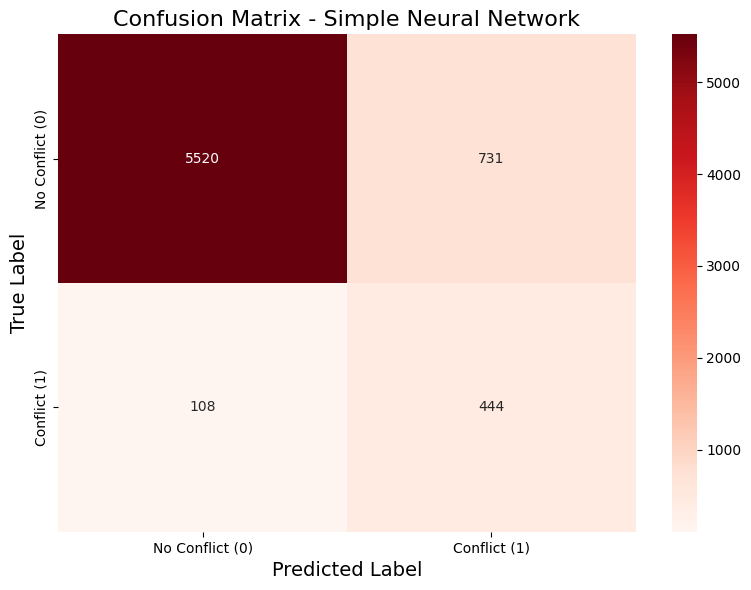

In [14]:
# Use the same preprocessing steps as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Simple Neural Network Class
class SimpleConflictPredictor(nn.Module):
    def __init__(self, input_size):
        super(SimpleConflictPredictor, self).__init__()
        
        # Simple architecture: 2 hidden layers
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        
        # Activation functions
        # ReLU for hidden layers
        self.relu = nn.ReLU()
        # Sigmoid for binary output          
        self.sigmoid = nn.Sigmoid()    
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# Prepare data (CPU only)
input_size = X_train_smote.shape[1]
print(f"Input features: {input_size}")

# Convert to PyTorch tensors (CPU)
X_train_tensor = torch.FloatTensor(X_train_smote)
y_train_tensor = torch.FloatTensor(y_train_smote.values.reshape(-1, 1))
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1, 1))

# Create data loaders
batch_size = 128
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = SimpleConflictPredictor(input_size)
print(f"Model architecture:")
print(model)

# Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy for binary classification
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  # SGD optimizer

# Training function
def train_simple_model(model, train_loader, criterion, optimizer, num_epochs=50):
    model.train()
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            avg_loss = running_loss / len(train_loader)
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Train the model
print("\nTraining Simple Neural Network with SGD...")
train_simple_model(model, train_loader, criterion, optimizer, num_epochs=100)

# Evaluation
def evaluate_simple_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_preds = (test_outputs > 0.5).float()
        
        # Convert to numpy
        y_test_np = y_test.numpy().flatten()
        y_pred_np = test_preds.numpy().flatten()
        
        # Calculate metrics
        accuracy = (test_preds.flatten() == y_test.flatten()).float().mean().item()
        recall = recall_score(y_test_np, y_pred_np)
        precision = precision_score(y_test_np, y_pred_np)
        f1 = f1_score(y_test_np, y_pred_np)
        
        return accuracy, recall, precision, f1, y_pred_np

# Evaluate the model
accuracy, recall, precision, f1, y_pred_nn = evaluate_simple_model(model, X_test_tensor, y_test_tensor)

print("\n--- Simple Neural Network Results ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")

# Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
print(f"\nConfusion Matrix:")
print(cm_nn)

print(f"Neural Network Recall: {recall:.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Conflict (0)', 'Conflict (1)'],
            yticklabels=['No Conflict (0)', 'Conflict (1)'])
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix - Simple Neural Network', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
# Add LaTeX table generation for the simple network
results_dict = classification_report(y_test, y_pred_nn, output_dict=True)

print(f"\n--- LaTeX Results Table ---")
print(f"$$")
print(f"\\begin{{array}}{{lcccc}}")
print(f"\\text{{Class}} & \\text{{Precision}} & \\text{{Recall}} & \\text{{F1-score}} & \\text{{Support}} \\\\")
print(f"\\hline")
print(f"0 & {results_dict['0']['precision']:.2f} & {results_dict['0']['recall']:.2f} & {results_dict['0']['f1-score']:.2f} & {int(results_dict['0']['support'])} \\\\")
print(f"1 & {results_dict['1']['precision']:.2f} & {results_dict['1']['recall']:.2f} & {results_dict['1']['f1-score']:.2f} & {int(results_dict['1']['support'])} \\\\")
print(f"\\hline")
print(f"\\text{{Accuracy}} & {accuracy:.2f} &  &  & {int(results_dict['macro avg']['support'])} \\\\")
print(f"\\text{{Macro avg}} & {results_dict['macro avg']['precision']:.2f} & {results_dict['macro avg']['recall']:.2f} & {results_dict['macro avg']['f1-score']:.2f} & {int(results_dict['macro avg']['support'])} \\\\")
print(f"\\text{{Weighted avg}} & {results_dict['weighted avg']['precision']:.2f} & {results_dict['weighted avg']['recall']:.2f} & {results_dict['weighted avg']['f1-score']:.2f} & {int(results_dict['weighted avg']['support'])} \\\\")
print(f"\\end{{array}}")
print(f"$$")

# Also create a clean LaTeX table format
publication_metrics = pd.DataFrame({
    'Class': ['No Conflict (0)', 'Conflict (1)', 'Macro Avg', 'Weighted Avg'],
    'Precision': [
        results_dict['0']['precision'],
        results_dict['1']['precision'], 
        results_dict['macro avg']['precision'],
        results_dict['weighted avg']['precision']
    ],
    'Recall': [
        results_dict['0']['recall'],
        results_dict['1']['recall'],
        results_dict['macro avg']['recall'], 
        results_dict['weighted avg']['recall']
    ],
    'F1-Score': [
        results_dict['0']['f1-score'],
        results_dict['1']['f1-score'],
        results_dict['macro avg']['f1-score'],
        results_dict['weighted avg']['f1-score']
    ],
    'Support': [
        int(results_dict['0']['support']),
        int(results_dict['1']['support']),
        int(results_dict['macro avg']['support']),
        int(results_dict['weighted avg']['support'])
    ]
})

print("\n=== Standard LaTeX Table ===")
latex_table = publication_metrics.round(4).to_latex(
    index=False, 
    escape=False,
    column_format='lcccc',
    caption='Simple Neural Network Classification Results',
    label='tab:nn_results'
)
print(latex_table)

# Summary for comparison
print(f"\n=== Simple Neural Network Summary ===")
print(f"Architecture: 2 hidden layers (64, 32 neurons)")
print(f"Optimizer: SGD with momentum (lr=0.01)")
print(f"Training epochs: 50")
print(f"Threshold: 0.5 (default)")
print(f"Final performance:")
print(f"- Accuracy: {accuracy:.1%}")
print(f"- Recall: {recall:.1%}")
print(f"- Precision: {precision:.1%}")
print(f"- F1-Score: {f1:.3f}")


--- LaTeX Results Table ---
$$
\begin{array}{lcccc}
\text{Class} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Support} \\
\hline
0 & 0.98 & 0.88 & 0.93 & 6251 \\
1 & 0.38 & 0.80 & 0.51 & 552 \\
\hline
\text{Accuracy} & 0.88 &  &  & 6803 \\
\text{Macro avg} & 0.68 & 0.84 & 0.72 & 6803 \\
\text{Weighted avg} & 0.93 & 0.88 & 0.90 & 6803 \\
\end{array}
$$

=== Standard LaTeX Table ===
\begin{table}
\caption{Simple Neural Network Classification Results}
\label{tab:nn_results}
\begin{tabular}{lcccc}
\toprule
Class & Precision & Recall & F1-Score & Support \\
\midrule
No Conflict (0) & 0.980800 & 0.883100 & 0.929400 & 6251 \\
Conflict (1) & 0.377900 & 0.804300 & 0.514200 & 552 \\
Macro Avg & 0.679300 & 0.843700 & 0.721800 & 6803 \\
Weighted Avg & 0.931900 & 0.876700 & 0.895700 & 6803 \\
\bottomrule
\end{tabular}
\end{table}


=== Simple Neural Network Summary ===
Architecture: 2 hidden layers (64, 32 neurons)
Optimizer: SGD with momentum (lr=0.01)
Training epochs: 50
Threshol